# Projeto Teste A/B em campanha de geoespacial Marketing Analytics
>>Vamos verificar se há diferença significativa na taxa média de conversão entre os grupos A e B de regiões diferentes

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
# Carregando os dados

df = pd.read_csv('dataset.csv')

In [3]:
df.head()

,usuario_id,grupo,latitude,longitude,conversao
0,1,A,35.669109,6.869443,1
1,2,B,6.497346,-7.494524,1
2,3,A,-34.285029,-170.768856,0
3,4,A,56.483104,-57.150782,1
4,5,A,33.251611,-43.129577,0


In [4]:
df.shape

(1000, 5)

### Como conduzir um teste A/B - teste de Hipóteses

>>Para conduzir um Teste A/B o primeiro passo é definir as hipóteses. As hipóteses são normalmente divididas em **hipótese nula (H0) e hipótese alternativa (H1)**. Vamos definir as hipóteses para nosso problema:

* **Hipótese Nula ($H_0$):**

A hipótese nula afirma que não há diferença significativa na taxa média de conversão entre os grupos A e B. Ou seja, $H_0: pA = pB$.

$pA$ é a taxa média de conversão do grupo A

$pB$ é a taxa média de conversão do grupo B

* **Hipótese Alternativa ($H_1$):**

A hipótese alternativa afirma que há uma diferença significativa na taxa média de conversão entre os grupos A e B. Ou seja, $H_1: pA \neq pB$.


#### **Passos Para o Teste de Hipóteses:**

***1- Definir o Nível de Significância ($\alpha$)***

    O nível de significância comum é 0.05, o que indica que estamos dispostos a aceitar um risco de 5% de rejeitar a hipótese nula quando ela é verdadeira.

***2- Calcular a Estatística de Teste***

    Use um teste estatístico adequado (por exemplo, teste t de Student ou teste de proporção) para comparar as taxas de conversão entre os dois grupos.

***3- Tomar uma Decisão***

    Compare o valor-p obtido com o nível de significância.

>Se valor-p <= $\alpha$, rejeitamos a hipótese nula e aceitamos a hipótese alternativa.
>
>Se valor-p > $\alpha$, não rejeitamos a hipótese nula. Ou seja, falhamos em rejeitar a $H_0$.

#### Explorando os dados e Calculando a taxa média de conversão

In [5]:
# Calculando a taxa de convresão por grupo

taxa_conversao = df.groupby('grupo')['conversao'].mean()
taxa_conversao

grupo
A    0.300000
B    0.315686
Name: conversao, dtype: float64

In [6]:
# Separando os grupos

grupo_A = df[df['grupo'] == 'A']
grupo_B = df[df['grupo'] == 'B']

In [7]:
# Calculo das taxas média de conversão separadamente

taxa_conversao_A = grupo_A['conversao'].mean()
taxa_conversao_B = grupo_B['conversao'].mean()

In [8]:
taxa_conversao_A

np.float64(0.3)

In [9]:
taxa_conversao_B

np.float64(0.3156862745098039)

### Aplicando Teste Estatístico Apropriado

>> O teste **t de Student** é um teste estatístico paramétrico **usado para determinar se há uma diferença significativa entre as médias de dois grupos**. É amplamente utilizado quando os dados são aproximadamente normalmente distribuídos e as variâncias dos grupos são homogêneas.

**Hipóteses do Teste**

    Hipótese Nula (H0): Não há diferença significativa entre as médias dos grupos.
    Hipótese Alternativa (H1): Há uma diferença significativa entre as médias dos grupos.

**O teste t de Student é uma ferramenta estatística poderosa, mas possui certas suposições que precisam ser atendidas para que os resultados sejam válidos. Aqui estão as principais suposições:**

1. Normalidade
2. Independência das Amostras
3. Homogeneidade das Variâncias

#### 1. Teste de normalidade | Teste de shapiro-Wilk para normalidade

In [10]:
shapiro_A = stats.shapiro(grupo_A['conversao'])
shapiro_B = stats.shapiro(grupo_B['conversao'])
print(f'Teste de Shapiro-Wilk grupo A: {shapiro_A}')
print(f'Teste de Shapiro-Wilk grupo B: {shapiro_B}')

Teste de Shapiro-Wilk grupo A: ShapiroResult(statistic=np.float64(0.5755484295691086), pvalue=np.float64(8.305357450336786e-33))
Teste de Shapiro-Wilk grupo B: ShapiroResult(statistic=np.float64(0.585129503103347), pvalue=np.float64(4.3919138194577314e-33))


**A interpretação dos resultados do teste de Shapiro-Wilk para normalidade é baseada no valor-p (p-value) obtido:**

* Hipótese Nula (H0): Os dados são normalmente distribuídos.
* Hipótese Alternativa (H1): Os dados não são normalmente distribuídos.

**Interpretação dos Resultados:**

Para ambos os grupos, A e B, tivemos resultados muito baixos para a estatística do teste e valores-p extremamente pequenos (próximos de zero).

* Tomada de Decisão:

  Se o valor p for menor que $\alpha$, rejeitamos a hipótese nula.
  
  Se o valor p for maior ou igual a $\alpha$, não rejeitamos a hipótese nula.

* Resultados obtidos:

        Grupo A: p-value = 8.305357450336786e-33
        Grupo B: p-value = 4.3919138194577314e-33

**Conclusão:** Para os grupos A e B o valor p é significativamente menor que 0.05. Isso significa que rejeitamos a hipótese nula de que os dados são normalmente distribuidos. Portanto, os dados dos grupos A e B não são normalmente distribuidos

**Ações a tomar:**

    Como os dados não são normalmente distribuidos, a suposição de NORMALIDADE do teste t de Student não é atendida. Nesse caso podemos considerar os seguintes passos:

* **Transformação dos dados**

        Tentamos transformar os dados para aproxima-los de uma distribuição normal

* **Testes não parametrico**

        Usamos um teste nçao parametrico que não assume normalidade, como um teste de Mann-Whitney U (conhecido como teste de Wilcoxon rank-sum)

**`Obs:`** ***`Já não podemos usar o teste t studant, mas vamos terminar de verificar as suposições`***

#### 2. Independência das amostras

A independência significa que uma observação não influencia a outra. O problema é que não temos informação suficiente no dataset para provar a independência.

#### 3. Teste de Homogeneidade das Variâncias | Teste de Levene

In [12]:
# Verificação da homogeneidade das variancias

levene_test = stats.levene(grupo_A['conversao'], grupo_B['conversao'])
print(f'Teste de Levene para homogeneidade: {levene_test}')

Teste de Levene para homogeneidade: LeveneResult(statistic=np.float64(0.2880082452976037), pvalue=np.float64(0.5916193377766582))


#### A interpretação do resultado do teste de Levene para homogeneidade das variâncias envolve os seguintes passos:

**Hipóteses do Teste de Levene**

* Hipótese Nula ($H_0$): As variâncias dos dois grupos são iguais (homogeneidade das variâncias).
* Hipótese Alternativa ($H_1$): As variâncias dos dois grupos são diferentes (heterogeneidade das variâncias).

**Interpretação dos Resultados**

Tomada de Decisão:

* Se o valor $p$ for menor que $\alpha$, rejeitamos a hipótese nula.
* Se o valor $p$ for maior ou igual a $\alpha$, não rejeitamos a hipótese nula.

Resultados Obtidos:

* Statistic: 0.2880082452976037
* p-value: 0.5916193377766582

**Conclusão:**
O valor-p do teste de Levene é 0.5916193377766582, que é significativamente maior que 0.05. Portanto, não rejeitamos a hipótese nula.

As variâncias dos dois grupos (A e B) são consideradas iguais. **A suposição de homogeneidade das variâncias é atendida para o teste t de Student**, o que significa que podemos assumir que as variâncias dos grupos A e B são aproximadamente iguais.

**Ações a Tomar:**

Dado que a suposição de homogeneidade das variâncias é atendida, Nós poderiamos proceder com o teste t de Student padrão para comparar as médias dos dois grupos. 

No entanto, como os dados não são normalmente distribuídos (conforme determinado pelos resultados do teste de Shapiro-Wilk), seria mais apropriado usar um teste não paramétrico como o teste de Mann-Whitney U para comparar as conversões entre os grupos A e B.

### O teste de shapiro-Wilk violou uma das suposições (normalidade da distribuição), desta forma não deveriamos continuar com o teste parametrico t de Studant

#### Porem vamos aplica-lo mesmo assim!


*`OBS: Devemos descartar o reusltado pois não atendemos todas as suposições para aplicação`*

In [13]:
# Test t de Studant para comparar vas medias de conversão

t_stats, p_val = stats.ttest_ind(grupo_A['conversao'], grupo_B['conversao'])

In [14]:
print(f'Taxa de conversão do Grupo A: {grupo_A["conversao"].mean()}')
print(f'Taxa de conversão do Grupo B: {grupo_B["conversao"].mean()}')
print("Estatistica t:", t_stats)
print("Valor p:", p_val)

Taxa de conversão do Grupo A: 0.3
Taxa de conversão do Grupo B: 0.3156862745098039
Estatistica t: -0.5366639966474401
Valor p: 0.5916193377768858


In [15]:
# Interpretação dos resultados:

if p_val< 0.05:
    print('Rejeitamos a h0. Diferença estatisticamente significativa entre os grupos A e B')
else:
    print('Não há Diferença estatisticamente significativa entre os gurpos A e B')

Não há Diferença estatisticamente significativa entre os gurpos A e B


### Aplicando Teste Não Paramétrico:

O teste de Mann-Whitney U, também conhecido como teste de Wilcoxon rank-sum, é um teste não paramétrico utilizado para comparar duas amostras independentes. **Ele é utilizado quando as suposições de normalidade necessárias para o teste t de Student não são atendidas.**

O teste de Mann-Whitney U verifica se há uma diferença significativa entre as distribuições de duas amostras independentes. **Ele é frequentemente utilizado como uma alternativa ao teste t de Student quando os dados não são normalmente distribuídos.**

**Hipóteses do Teste**

* Hipótese Nula ($H_0$): As distribuições das duas populações são iguais, ou seja, as duas amostras provêm da mesma distribuição.

* Hipótese Alternativa ($H_1$): As distribuições das duas populações são diferentes, ou seja, as duas amostras provêm de distribuições diferentes.

Suposições

* As amostras são independentes.
* As observações são ordinalmente mensuráveis.
* O teste não assume normalidade das amostras.

In [16]:
# Teste de Mann-Whitney U

u_stat, p_val_mw = stats.mannwhitneyu(grupo_A['conversao'], grupo_B['conversao'])

In [17]:
print(f'Estatistica U: {u_stat}')
print(f'Valor p (Mann-Whitney): {p_val_mw}')

Estatistica U: 122990.0
Valor p (Mann-Whitney): 0.5914621529131736


In [18]:
# Interpretando os resultados:

alpha = 0.05
if p_val_mw < alpha:
    print('Rejeitamos a h0. Diferença estatisticamente significativa entre os grupos A e B')
else:
    print('Não há Diferença estatisticamente significativa entre os gurpos A e B')

Não há Diferença estatisticamente significativa entre os gurpos A e B


### Distribuição Geográfica dos Grupos A e B

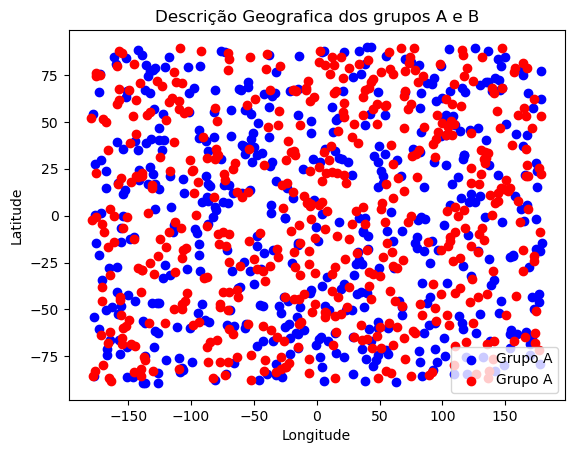

In [19]:
# plot

plt.scatter(grupo_A['longitude'], grupo_A['latitude'], c='blue', label='Grupo A')
plt.scatter(grupo_B['longitude'], grupo_B['latitude'], c='red', label='Grupo A')

plt.xlabel('Longitude')
plt.ylabel('Latitude')


plt.legend()
plt.title("Descrição Geografica dos grupos A e B")

plt.show()

Não há diferença de taxa de conversão entre os grupo EM TERMOS GEOGRAFICOS

### Conclusão

Com base na analise dos dados não temos evidências estatísticas para afirmar que a campanha de marketing apesenta diferença entre as regiões geograficas dos usuários.

A região geografica não tem influência na taxa média de conversão dos dados analisados.

# Fim